# Slow Dynamics and High Variability in Networks with Clustered Connections




# Converting difference of exponential filter to an ODE

TODO

# Initialize default model parameters

In [ ]:
from dataclasses import dataclass
from brian2 import ms, second, volt
from typing import Tuple
import numpy as np

@dataclass
class ClusterParams:
    enabled: bool = False
    R_ee: float = 1.0 # ratio of p_in / p_out. 1.0 implies no clustering
    cluster_size: int = 80 # num neurons in each cluster
    weight_scaling_factor: float = 1.9 # ƒactor to scale excitatory synaptic weight for in-cluster connections


    def calculate_p_in_out(self, N_E: int, p_avg: float) -> Tuple[float, float]:
        # TODO: Look into this. There might be a bug here
        Q = N_E / self.cluster_size  # number of clusters
        
        # Solve: p_out * (R_ee + Q - 1) / Q = p_avg
        p_out = p_avg * Q / (self.R_ee + Q - 1)
        p_in = self.R_ee * p_out
        
        return p_in, p_out


class ModelParams:
    """Parameters for the clustered network model."""
    
    def __init__(
        self,
        # Network size
        N_E=4000,              # number of excitatory neurons
        N_I=1000,              # number of inhibitory neurons
        N_ref=5000,            # reference network size (for weight scaling)
        seed=42,               # random seed
        # Neuron parameters
        refractory_t=5*ms,     # refractory period
        tau_e=15*ms,           # membrane time constant for E neurons
        tau_i=10*ms,           # membrane time constant for I neurons
        Vt=1,                  # spike threshold
        Vr=0,                  # reset potential
        # Synaptic time constants
        t1=1*ms,               # exponential filter time constant 1
        t2_e=3*ms,             # exponential filter time constant 2 (excitatory)
        t2_i=2*ms,             # exponential filter time constant 2 (inhibitory)
        # Reference synaptic weights (calibrated for N=5000)
        j_ee_ref=0.024,        # E -> E
        j_ie_ref=0.014,        # E -> I 
        j_ei_ref=-0.045,       # I -> E (negative for inhibition)
        j_ii_ref=-0.057,       # I -> I
        # Connection probabilities
        p_conn_e=0.2,          # E -> E connection probability
        p_conn_i=0.5,          # connection probability involving I
        # Mean equilibrium
        mu_e_range=(1.1, 1.2),    # external input range for E neurons
        mu_i_range=(1.0, 1.05),   # external input range for I neurons
        # Initial inputs
        n_input=10,            # number of input spike sources
        # Simulation parameters
        dt=0.1*ms,             # integration timestep
        analysis_start_t=1.5*second, # time to start statistical analysis
        analysis_window_t=1.5*second, # time window to perform statistical analysis
        duration=3*second,     # simulation duration
        # Plotting
        voltage_scale=15*volt, # for converting to physical units
    ):
        self.N_E = N_E
        self.N_I = N_I
        self.N_ref = N_ref
        self.seed = seed
        self.refractory_t = refractory_t
        self.tau_e = tau_e
        self.tau_i = tau_i
        self.Vt = Vt
        self.Vr = Vr
        self.t1 = t1
        self.t2_e = t2_e
        self.t2_i = t2_i
        self.j_ee_ref = j_ee_ref
        self.j_ei_ref = j_ei_ref
        self.j_ie_ref = j_ie_ref
        self.j_ii_ref = j_ii_ref
        self.p_conn_e = p_conn_e
        self.p_conn_i = p_conn_i
        self.mu_e_range = mu_e_range
        self.mu_i_range = mu_i_range
        self.n_input = n_input
        self.dt = dt
        self.analysis_start_t = analysis_start_t
        self.analysis_window_t = analysis_window_t
        self.duration = duration
        self.voltage_scale = voltage_scale
    
    @property
    def N_total(self):
        """Total number of neurons."""
        return self.N_E + self.N_I
    
    @property
    def scaled_weights(self):
        """
        Scale synaptic weights based on network size.
        
        Weights scale as 1/sqrt(N) to maintain constant variance 
        of total synaptic input as network size changes.
        """
        scale_factor = np.sqrt(self.N_ref / self.N_total)
        return (
            self.j_ee_ref * scale_factor,
            self.j_ei_ref * scale_factor,
            self.j_ie_ref * scale_factor,
            self.j_ii_ref * scale_factor,
        )
    
    def get_rng(self):
        """Return a numpy random generator with the configured seed."""
        return np.random.default_rng(seed=self.seed)

# A base, homogenous model

In [115]:
def create_clusters(cluster_size, total):
    """
    Split indices 0..total into contiguous segments of cluster_size.
    We assume that the total number of neurons is divisible by cluster_size (i.e no leftovers)

    Returns 2D array of shape (num_clusters, cluster_size)
    """
    assert total % cluster_size == 0, "all clusters must have equal size"
    num_clusters = total // cluster_size
    idx = np.arange(0, total).reshape(num_clusters, cluster_size)
    return idx

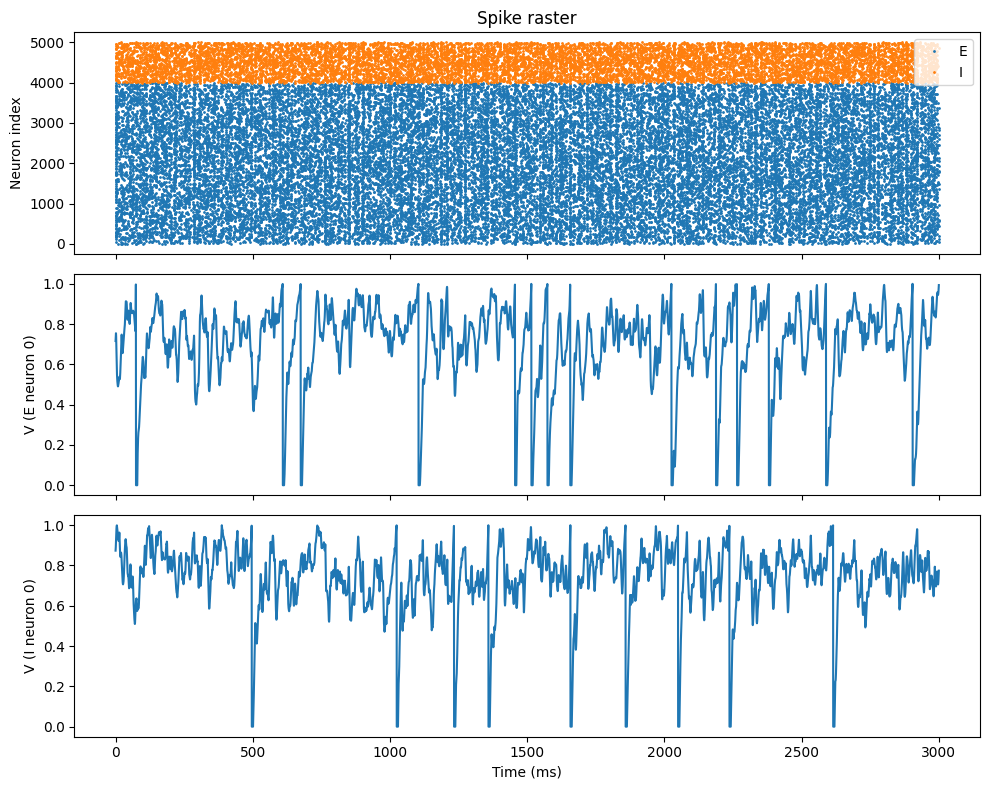

In [ ]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# --- Model parameters ---
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=4.5)
rng = params.get_rng()

# Unpack scaled weights
j_ee, j_ei, j_ie, j_ii = params.scaled_weights
t1 = params.t1
t2_e = params.t2_e
t2_i = params.t2_i

eqs_base = """
dV/dt = (mu - V) / tau + Isyn_e + Isyn_i : 1 (unless refractory)
Isyn_e = g_e : 1/second
Isyn_i = g_i : 1/second

dg_e/dt = (x_e - g_e) / t2_e : 1/second
dx_e/dt = -x_e / t1 : 1/second

dg_i/dt = (x_i - g_i) / t2_i : 1/second
dx_i/dt = -x_i / t1 : 1/second

mu : 1      # per-neuron bias (external input)
tau : second  # per-neuron membrane time constant
"""

# Excitatory neurons include cluster_id for clustered connectivity
eqs_E = eqs_base + """
cluster_id : integer (constant)  # cluster membership for E->E clustering
"""

# Excitatory population
E = NeuronGroup(
    params.N_E,
    eqs_E,
    threshold=f'V > {params.Vt}',
    reset=f'V = {params.Vr}',
    refractory=params.refractory_t,
    method='euler',
    dt=params.dt
)
# Inhibitory population
I = NeuronGroup(
    params.N_I,
    eqs_base,
    threshold=f'V > {params.Vt}',
    reset=f'V = {params.Vr}',
    refractory=params.refractory_t,
    method='euler',
    dt=params.dt
)

# Set up bias and initial voltages randomly 
E.mu = rng.uniform(*params.mu_e_range, size=params.N_E)
E.V = rng.uniform(params.Vr, params.Vt, size=params.N_E)
I.mu = rng.uniform(*params.mu_i_range, size=params.N_I)
I.V = rng.uniform(params.Vr, params.Vt, size=params.N_I)

# Set time constants
E.tau = params.tau_e
I.tau = params.tau_i

# Set up synapses for connections involving inhibitory neurons
# E -> I
S_ie = Synapses(E, I, 'w: 1', on_pre='x_e_post += w/t1', dt=params.dt)
# I -> E
S_ei = Synapses(I, E, 'w: 1', on_pre='x_i_post += w/t1', dt=params.dt)
# I -> I
S_ii = Synapses(I, I, 'w: 1', on_pre='x_i_post += w/t1', dt=params.dt)

# Connect inhibitory synapses (same probability for all)
S_ei.connect(p=params.p_conn_i)
S_ie.connect(p=params.p_conn_i)
S_ii.connect(p=params.p_conn_i)

S_ie.w = j_ie
S_ei.w = j_ei
S_ii.w = j_ii

# E -> E connections: handle clustering if enabled
# Uses a single Synapses object with cluster-aware connectivity
S_ee = Synapses(E, E, 'w: 1', on_pre='x_e_post += w/t1', dt=params.dt)

if cluster_params.enabled:
    p_in, p_out = cluster_params.calculate_p_in_out(params.N_E, params.p_conn_e)
    print(p_in, p_out)
    
    # Assign cluster IDs to excitatory neurons
    cluster_idxs = create_clusters(cluster_params.cluster_size, params.N_E)
    for cid, indices in enumerate(cluster_idxs):
        E.cluster_id[indices] = cid
    
    # Connect with different probabilities based on cluster membership
    # Brian2 automatically creates cluster_id_pre and cluster_id_post
    # Note: Brian2 doesn't support Python ternary syntax, so we use boolean arithmetic:
    # same_cluster=1 -> p_out + (p_in - p_out)*1 = p_in
    # same_cluster=0 -> p_out + (p_in - p_out)*0 = p_out
    S_ee.connect(
        condition='i != j',
        p='p_out + (p_in - p_out) * (cluster_id_pre == cluster_id_post)', # 
        namespace={'p_in': p_in, 'p_out': p_out}
    )
    
    # Set weights: stronger for within-cluster, baseline for between-cluster
    same_cluster = (E.cluster_id[S_ee.i] == E.cluster_id[S_ee.j])
    S_ee.w[same_cluster] = j_ee * cluster_params.weight_scaling_factor
    S_ee.w[~same_cluster] = j_ee
else:
    # No clustering: uniform connectivity
    E.cluster_id = 0  # all neurons in "cluster 0"
    S_ee.connect(condition='i != j', p=params.p_conn_e)
    S_ee.w = j_ee

# --- External input to kick-start activity ---
# Send a spike to a few E neurons at random times
indices = np.arange(params.n_input)
times = rng.uniform(1, 100, size=params.n_input) * ms
inp = SpikeGeneratorGroup(params.n_input, indices, times, dt=params.dt)

S_inp = Synapses(inp, E[:params.n_input], on_pre='x_e_post += 1/t1', dt=params.dt)
S_inp.connect(j='i')  # one-to-one

# --- Monitors ---
M_E = StateMonitor(E, variables=['V'], record=True)
M_I = StateMonitor(I, variables=['V'], record=True)
spk_E = SpikeMonitor(E)
spk_I = SpikeMonitor(I)

run(params.duration)

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Raster plot
axes[0].plot(spk_E.t/ms, spk_E.i, '.', markersize=2, label='E')
axes[0].plot(spk_I.t/ms, spk_I.i + params.N_E, '.', markersize=2, label='I')
axes[0].set_ylabel('Neuron index')
axes[0].set_title('Spike raster')
axes[0].legend(loc='upper right')

# Example E neuron voltage
axes[1].plot(M_E.t/ms, M_E.V[0])
axes[1].set_ylabel('V (E neuron 0)')

# Example I neuron voltage
axes[2].plot(M_I.t/ms, M_I.V[0])
axes[2].set_ylabel('V (I neuron 0)')
axes[2].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

In [105]:
def firing_rate(spike_monitor, num_in_population, start_t, window_t):
    # The paper only counts spikes after 1.5s, and looks for 1.5s - we do the same
    mask = (spike_monitor.t >= start_t) & (spike_monitor.t <= start_t + window_t)
    spikes = spike_monitor.i[mask]
    # For each neuron in the population (minlength is set), count the spikes
    spike_counts = np.bincount(spikes, minlength=num_in_population)
    # Return a simple time averaged calculation of firing rate
    return spike_counts / window_t

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)


Text(0.5, 1.0, 'Firing Rate for Unclustered Network')

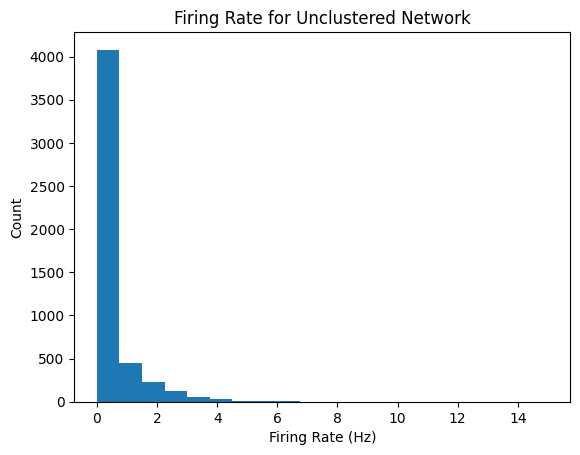

In [119]:
firing_rates_e = firing_rate(spk_E, params.N_E, params.analysis_start_t, params.analysis_window_t)
firing_rates_i = firing_rate(spk_I, params.N_I, params.analysis_start_t, params.analysis_window_t)
print(firing_rates_e.shape, firing_rates_i.shape)
firing_rates = np.concatenate([firing_rates_e, firing_rates_i])
print(firing_rates.shape)

fig, ax = plt.subplots()

ax.hist(firing_rates, bins=20, range=(0,15))
ax.set_xlabel('Firing Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title("Firing Rate for Unclustered Network")




In [ ]:
class NeuronNetwork():
    def __init__(self, params: ModelParams, clustering_params: ClusterParams):
        self.params = params
        self._initialize()

    def _initialize(self):
        pass

    def run(self):
        pass

    def firing_rate(self):
        pass

    def spikes(self):
        pass

    